# Hedge cambial de uma exportadora com forwards de USD/BRL

**O caso:** uma exportadora brasileira vai receber **USD 1 milhão em 90 dias úteis**. Se o dólar cair até lá, a receita em reais encolhe. Este notebook responde, na ordem:

1. Qual é o **preço justo** do forward hoje?
2. Como o contrato se comporta ao longo da vida (**marcação a mercado**)?
3. Quanto risco o hedge elimina — total, parcial e **em camadas**?

Base teórica: Hull, *Options, Futures and Other Derivatives*, caps. 1–3, 5–6.

In [1]:
import sys
sys.path.append('..')

import numpy as np

from src.pricing import forward_price, forward_mtm
from src.hedge import (simulate_spot_paths, pnl_unhedged, pnl_hedged,
                       layered_hedge, hedge_effectiveness)
from src.plots import (plot_revenue_distribution, plot_forward_mtm,
                       plot_pnl_by_hedge_ratio)

# Cenário-base
SPOT = 5.00       # BRL por USD
R_DOM = 0.12      # CDI ~12% a.a. (base 252)
R_FOR = 0.05      # taxa USD ~5% a.a.
DAYS = 90         # dias úteis até o recebimento
VOL = 0.15        # vol anualizada do USD/BRL
NOTIONAL = 1_000_000  # USD a receber
N_SIMS = 20_000

## 1. Preço justo do forward

Pela **paridade coberta de juros**, o forward não é uma aposta sobre o dólar futuro — é o preço que elimina arbitragem entre aplicar em CDI e aplicar em dólar:

$$F = S \cdot \frac{(1 + r_{BRL})^{t}}{(1 + r_{USD})^{t}}, \qquad t = \frac{\text{dias úteis}}{252}$$

Como o juro brasileiro é maior, o dólar a termo negocia **com prêmio** sobre o spot (o famoso *forward points* positivo do USD/BRL).

In [2]:
F = forward_price(SPOT, R_DOM, R_FOR, DAYS)
premio = F / SPOT - 1
print(f'Spot:            R$ {SPOT:.4f}')
print(f'Forward 90 du:   R$ {F:.4f}')
print(f'Prêmio a termo:  {premio:.2%}')

Spot:            R$ 5.0000
Forward 90 du:   R$ 5.1166
Prêmio a termo:  2.33%


## 2. Marcação a mercado (MTM)

No fechamento, o contrato vale **zero** — ninguém paga para entrar num forward a preço justo. Depois, conforme o câmbio se move, o contrato ganha ou perde valor. Para a exportadora (vendida em USD a termo), o MTM é:

$$MTM_{short} = \frac{(F_{contratado} - F_{atual}) \cdot N}{(1 + r_{BRL})^{t}}$$

In [3]:
# Sanidade: MTM no fechamento é zero
print(f'MTM no dia 0: R$ {forward_mtm(F, F, NOTIONAL, R_DOM, DAYS):,.2f}')

# Se o dólar cair para 4.80 faltando 45 du, o forward de mercado cai junto
F_novo = forward_price(4.80, R_DOM, R_FOR, 45)
mtm = forward_mtm(F, F_novo, NOTIONAL, R_DOM, 45, position='short')
print(f'Dólar a 4.80 faltando 45 du -> MTM da exportadora: R$ {mtm:,.0f}')

MTM no dia 0: R$ 0.00
Dólar a 4.80 faltando 45 du -> MTM da exportadora: R$ 255,719


O hedge ganhou valor exatamente quando a receita da empresa perdeu — essa é a mecânica de proteção. Vamos ver a distribuição completa via Monte Carlo.

## 3. Simulação do câmbio

Simulamos o USD/BRL como **movimento browniano geométrico** com drift zero (hipótese conservadora: o câmbio é um martingale — não apostamos em direção).

In [4]:
paths = simulate_spot_paths(SPOT, VOL, DAYS, N_SIMS, seed=42)
print(f'{N_SIMS:,} trajetórias simuladas')
print(f'Câmbio em 90 du: P5 = {np.percentile(paths[:, -1], 5):.2f} | '
      f'mediana = {np.median(paths[:, -1]):.2f} | '
      f'P95 = {np.percentile(paths[:, -1], 95):.2f}')

20,000 trajetórias simuladas
Câmbio em 90 du: P5 = 4.31 | mediana = 4.98 | P95 = 5.77


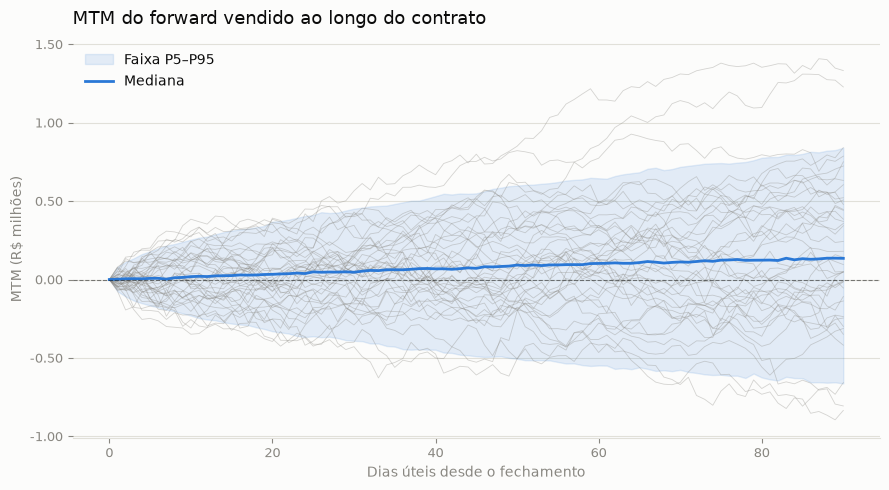

In [5]:
# MTM diário do forward vendido em cada cenário
mtm_paths = np.empty_like(paths)
for d in range(DAYS + 1):
    remaining = DAYS - d
    f_mercado = paths[:, d] * forward_price(1.0, R_DOM, R_FOR, remaining)
    mtm_paths[:, d] = forward_mtm(F, f_mercado, NOTIONAL, R_DOM,
                                  remaining, position='short')
plot_forward_mtm(mtm_paths[:2000]);

## 4. Com hedge vs sem hedge — o resultado central

Sem proteção, a receita em BRL é o notional convertido ao câmbio que vigorar no dia. Com o forward, a receita está travada em $N \cdot F$ hoje, aconteça o que acontecer.

In [6]:
receita_sem = pnl_unhedged(paths, NOTIONAL)
receita_com = pnl_hedged(paths, NOTIONAL, F, hedge_ratio=1.0)

print(f'{"":18}{"média":>14}{"desvio-padrão":>16}{"P5":>14}')
for nome, r in [('Sem hedge', receita_sem), ('Hedge 100%', receita_com)]:
    print(f'{nome:<18}{r.mean():>14,.0f}{r.std():>16,.0f}'
          f'{np.percentile(r, 5):>14,.0f}')

eff = hedge_effectiveness(receita_sem, receita_com)
print(f'\nO hedge de 100% eliminou {eff:.0%} da volatilidade da receita.')

                           média   desvio-padrão            P5
Sem hedge              5,002,690         446,218     4,307,705
Hedge 100%             5,116,586               0     5,116,586

O hedge de 100% eliminou 100% da volatilidade da receita.


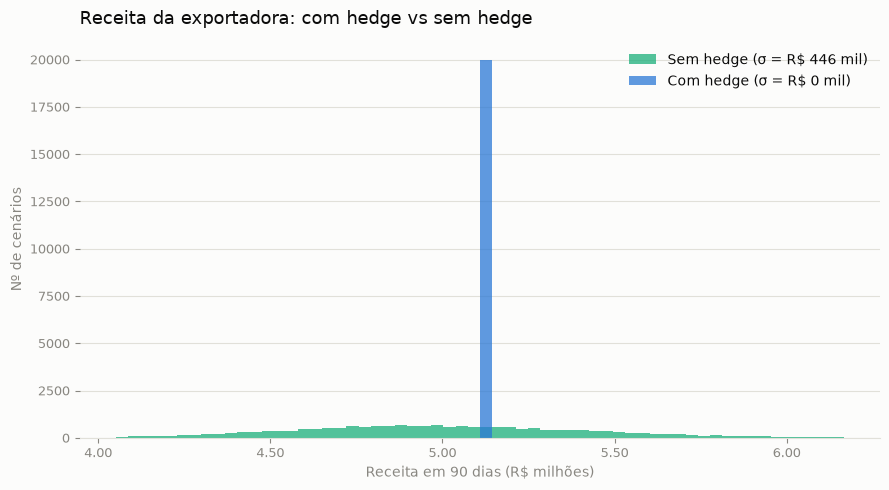

In [7]:
plot_revenue_distribution(receita_sem, receita_com);

Dois efeitos ao mesmo tempo:

- **A incerteza desaparece** — o desvio-padrão vai de ~R$ 446 mil para zero.
- **A média até sobe** — o prêmio a termo (diferencial de juros) joga a favor de quem vende dólar futuro. No Brasil, exportador que faz hedge **é pago para reduzir risco**.

*(No modelo não há basis risk: o forward casa perfeitamente com a data e o valor da exposição. Na prática — Hull, cap. 6 — datas quebradas e NDFs com ajuste deixam um resíduo pequeno de risco.)*

## 5. Hedge parcial: quanto proteger?

Nem toda empresa trava 100% — a exposição futura é incerta e o hedge tem custo de oportunidade se o dólar subir. Varremos o hedge ratio de 0% a 100%.

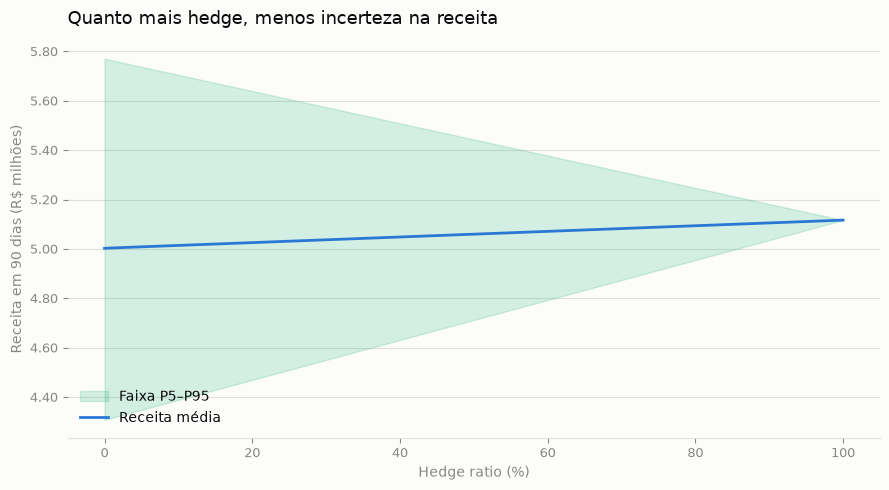

In [8]:
ratios = np.linspace(0, 1, 21)
receitas = np.stack([pnl_hedged(paths, NOTIONAL, F, r) for r in ratios])
plot_pnl_by_hedge_ratio(ratios, receitas);

A faixa de incerteza (P5–P95) colapsa **linearmente** sobre a média conforme o ratio sobe — com 80% de hedge sobra exatamente 20% da volatilidade original.

## 6. Hedge em camadas (prática de tesouraria)

Na vida real a tesouraria raramente trava tudo de uma vez: trava **1/3 da exposição a cada mês**, tomando o preço forward vigente em cada data. Isso dilui o risco de travar tudo num dia ruim (*timing risk*), ao custo de deixar parte da exposição aberta por mais tempo.

In [9]:
receita_camadas = layered_hedge(
    paths, NOTIONAL,
    schedule=[(0, 1/3), (21, 1/3), (42, 1/3)],  # 1/3 por mês
    r_dom=R_DOM, r_for=R_FOR,
)

print(f'{"":22}{"média":>14}{"desvio-padrão":>16}')
for nome, r in [('Sem hedge', receita_sem),
                ('Camadas (1/3 ao mês)', receita_camadas),
                ('Hedge 100% no dia 0', receita_com)]:
    print(f'{nome:<22}{r.mean():>14,.0f}{r.std():>16,.0f}')

eff_camadas = hedge_effectiveness(receita_sem, receita_camadas)
print(f'\nHedge em camadas eliminou {eff_camadas:.0%} da volatilidade.')

                               média   desvio-padrão
Sem hedge                  5,002,690         446,218
Camadas (1/3 ao mês)       5,090,264         163,667
Hedge 100% no dia 0        5,116,586               0

Hedge em camadas eliminou 63% da volatilidade.


## Conclusão

| Estratégia | O que faz | Resultado |
|---|---|---|
| Sem hedge | torce pelo câmbio | receita média R$ 5,0 mi, σ ≈ R$ 446 mil |
| Hedge 100% | trava tudo no dia 0 | receita **certa** de R$ 5,12 mi, σ = 0 |
| Camadas | trava 1/3 ao mês | elimina a maior parte do risco, mantém flexibilidade |

O forward transforma uma receita incerta numa receita conhecida — e, pelo diferencial de juros BRL×USD, ainda paga um prêmio para isso. O custo real do hedge é abrir mão do ganho nos cenários em que o dólar dispara.

**Conceitos aplicados:** paridade coberta de juros (base 252), marcação a mercado, movimento browniano geométrico, hedge ratio, hedge em camadas, basis risk.